## 📊 H3 배달 수요 지수 산출 파이프라인 핵심 요약

본 파이프라인은 인구수(양)와 배달 횟수(확률)를 곱해 총수요를 구하고, 이를 건물 크기(위치 가중치)에 따라 H3 헥사곤에 정밀하게 배분합니다.

### 1. 🧮 최종 배달 수요 산출 공식
* **[1단계] 행정동 총수요 산출**
  `행정동 총수요 = (심야 인구 × 집 배달 횟수) + (주간 잉여 인구 × 집 밖 배달 횟수)`
* **[2단계] H3 셀(격자) 단위 분배**
  `H3 셀 수요 = 행정동 총수요 × (해당 H3 셀 내 건물 연면적 / 행정동 전체 건물 연면적)`

---

### 2. 📂 실제 연산 투입 데이터셋 (3대 핵심)
| 데이터 역할 | 파일 / 출처 | 실제 연산에 쓰이는 핵심 값 (컬럼) |
| :--- | :--- | :--- |
| **수요의 양** | `LOCAL_PEOPLE_DONG_*.csv` | `TIME_CD` (거주/비거주 분류), `연령별 인구수` |
| **수요의 확률** | `외식업 조사` (코드 내 하드코딩) | `연령별 배달 횟수 가중치` (인구를 건수로 변환) |
| **수요의 위치** | `seoul_buildings.gpkg` | `geometry` (H3 매핑), `total_area` (공간 분배 가중치) |

---

### 3. 🔗 필수 인프라 데이터 (연결/접착용)
수치 계산에는 직접 들어가지 않지만, 공간을 병합하고 데이터 증발을 막기 위해 반드시 필요한 파일들입니다.

* **공간 테두리:** `00_data\BND_ADM_DONG_PG\BND_ADM_DONG_PG.shp` (건물 ↔ 행정동 소속 판별) 한반도 전체여서 서울시에 대해서 코드 내에서 다시 분할
* **코드 변환기:** `admin_code_crosswalk.csv` (인구 데이터의 행안부 코드 ↔ 지도 데이터의 통계청 코드 매핑)

In [1]:
import pandas as pd
import numpy as np
import glob
from pathlib import Path
import matplotlib.pyplot as plt

# 시각화용 한글 폰트 설정 (Windows 기준: Malgun Gothic / Mac 기준: AppleGothic)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 경로 설정 (현재 노트북 파일의 위치를 기준으로 설정)
# 만약 노트북이 'notebooks' 폴더 안에 있다면 BASE = Path("..").resolve() 로 변경하세요.
BASE = Path("..").resolve()
RAW = BASE / "00_data"
OUT = BASE / "processed"

# 크로스워크 파일 경로 (행정동 매핑용)
CROSSWALK = OUT / "admin_code_crosswalk.csv"

print(f"프로젝트 기본 경로: {BASE}")
print(f"원본 데이터 폴더: {RAW}")
print(f"가공 데이터 폴더: {OUT}")

프로젝트 기본 경로: C:\Users\jimin\Desktop\1_BITAmin_16기\skybase-seoul\skybase-seoul-v3
원본 데이터 폴더: C:\Users\jimin\Desktop\1_BITAmin_16기\skybase-seoul\skybase-seoul-v3\00_data
가공 데이터 폴더: C:\Users\jimin\Desktop\1_BITAmin_16기\skybase-seoul\skybase-seoul-v3\processed


In [2]:
# 생활인구 파일 탐색
fp_files = sorted(glob.glob(str(RAW / "LOCAL__" / "LOCAL_PEOPLE_DONG_*.csv")))
print(f"찾은 생활인구 파일: {len(fp_files)}개")

# 컬럼 영문 리네임 딕셔너리
rename_dict = {
    "시간대구분": "TIME_CD", "행정동코드": "행정동코드", "총생활인구수": "TOTAL_POP_ORG",
    "남자0세부터9세생활인구수": "M_00_CNT", "남자10세부터14세생활인구수": "M_10_CNT",
    "남자15세부터19세생활인구수": "M_15_CNT", "남자20세부터24세생활인구수": "M_20_CNT",
    "남자25세부터29세생활인구수": "M_25_CNT", "남자30세부터34세생활인구수": "M_30_CNT",
    "남자35세부터39세생활인구수": "M_35_CNT", "남자40세부터44세생활인구수": "M_40_CNT",
    "남자45세부터49세생활인구수": "M_45_CNT", "남자50세부터54세생활인구수": "M_50_CNT",
    "남자55세부터59세생활인구수": "M_55_CNT", "남자60세부터64세생활인구수": "M_60_CNT",
    "남자65세부터69세생활인구수": "M_65_CNT", "남자70세이상생활인구수": "M_70_CNT",
    "여자0세부터9세생활인구수": "F_00_CNT", "여자10세부터14세생활인구수": "F_10_CNT",
    "여자15세부터19세생활인구수": "F_15_CNT", "여자20세부터24세생활인구수": "F_20_CNT",
    "여자25세부터29세생활인구수": "F_25_CNT", "여자30세부터34세생활인구수": "F_30_CNT",
    "여자35세부터39세생활인구수": "F_35_CNT", "여자40세부터44세생활인구수": "F_40_CNT",
    "여자45세부터49세생활인구수": "F_45_CNT", "여자50세부터54세생활인구수": "F_50_CNT",
    "여자55세부터59세생활인구수": "F_55_CNT", "여자60세부터64세생활인구수": "F_60_CNT",
    "여자65세부터69세생활인구수": "F_65_CNT", "여자70세이상생활인구수": "F_70_CNT",
}

dfs = []
for fpath in fp_files:
    for enc in ("utf-8-sig", "utf-8", "cp949"):
        try:
            df = pd.read_csv(fpath, encoding=enc, index_col=False)
            break
        except (UnicodeDecodeError, KeyError):
            continue
    # 연월 컬럼 추가
    fname = Path(fpath).stem
    ym = fname.split("_")[-1]  # LOCAL_PEOPLE_DONG_202501 형태에서 끝부분 추출
    df["ym"] = ym
    dfs.append(df)

df_fp = pd.concat(dfs, ignore_index=True)
df_fp = df_fp.rename(columns=rename_dict)
df_fp = df_fp.drop(columns=["기준일ID"], errors="ignore")

print(f"전체 로드된 유동인구 행 수: {len(df_fp):,}")

찾은 생활인구 파일: 12개
전체 로드된 유동인구 행 수: 3,693,812


In [3]:
# 크로스워크 로드 및 타입 변환
crosswalk = pd.read_csv(CROSSWALK)
crosswalk = crosswalk.dropna(subset=["CSV_ADMI_CD"])
crosswalk["CSV_ADMI_CD"] = crosswalk["CSV_ADMI_CD"].astype(int).astype(str)
crosswalk["SHP_ADM_CD"] = crosswalk["SHP_ADM_CD"].astype(int).astype(str)

# 행정동코드 변환 및 inner join을 통한 서울시 필터링
df_fp["행정동코드"] = pd.to_numeric(df_fp["행정동코드"], errors="coerce")
df_fp = df_fp.dropna(subset=["행정동코드"])
df_fp["행정동코드"] = df_fp["행정동코드"].astype(int).astype(str)

df_fp = pd.merge(
    df_fp,
    crosswalk,
    left_on="행정동코드",
    right_on="CSV_ADMI_CD",
    how="inner",
)

print(f"매핑 후 최종 데이터 행 수: {len(df_fp):,}")

매핑 후 최종 데이터 행 수: 3,554,424


In [5]:
# 배달 수요율 CSV에서 연령별 배달 횟수 로드
DELIVERY_RATE_PATH = RAW / "최근+일주일간+배달+또는+포장+음식을+이용한+식사_20260511164501.csv"

def _load_delivery_rates(path):
    for enc in ("utf-8-sig", "utf-8", "cp949", "euc-kr"):
        try:
            raw_df = pd.read_csv(path, encoding=enc, header=None)
            break
        except (UnicodeDecodeError, Exception):
            continue
    # 전국 + 연령별 필터 (열 0=행정구분1, 열 1=행정구분2, 열 2=연령대)
    mask = (raw_df[0].astype(str).str.strip() == "전국")        
    (raw_df[1].astype(str).str.strip() == "연령별")
    age_rows = raw_df[mask].copy()
    
    AGE_MAP = {
        "18~29세": "20대", "30대": "30대", "40대": "40대",
        "50대": "50대", "60대": "60대", "60세 이상": "60대",
        "70대": "70대", "65세 이상": "70대", "70세 이상": "70대",
    }
    rates = {}
    for _, row in age_rows.iterrows():
        age_label = str(row[2]).strip()
        key = AGE_MAP.get(age_label)
        if key is None:
            continue
        try:
            home_rate = float(str(row[8]).replace("-", "0").replace(",", "."))
            out_rate  = float(str(row[13]).replace("-", "0").replace(",", "."))
        except (ValueError, IndexError):
            continue
        if key not in rates:
            rates[key] = {"home": home_rate, "out": out_rate}
    
    # Fallback defaults if CSV read fails or age groups missing
    fallback = {
        "20대": {"home": 1.5, "out": 0.5},
        "30대": {"home": 1.9, "out": 0.5},
        "40대": {"home": 1.4, "out": 0.5},
        "50대": {"home": 1.1, "out": 0.4},
        "60대": {"home": 0.8, "out": 0.3},
        "70대": {"home": 0.6, "out": 0.2},
    }
    for k, v in fallback.items():
        if k not in rates:
            rates[k] = v
    return rates

if DELIVERY_RATE_PATH.exists():
    delivery_rates = _load_delivery_rates(DELIVERY_RATE_PATH)
    print(f"배달 수요율 로드 완료 (CSV): {DELIVERY_RATE_PATH.name}")
else:
    print(f"배달 수요율 CSV 미확보 — 기본값 사용: {DELIVERY_RATE_PATH}")
    delivery_rates = {
        "20대": {"home": 1.5, "out": 0.5},
        "30대": {"home": 1.9, "out": 0.5},
        "40대": {"home": 1.4, "out": 0.5},
        "50대": {"home": 1.1, "out": 0.4},
        "60대": {"home": 0.8, "out": 0.3},
        "70대": {"home": 0.6, "out": 0.2},
    }

# 유동인구 컬럼과 연령대 매핑
age_col_mapping = {
    "20대": ["M_15_CNT", "M_20_CNT", "M_25_CNT", "F_15_CNT", "F_20_CNT", "F_25_CNT"],
    "30대": ["M_30_CNT", "M_35_CNT", "F_30_CNT", "F_35_CNT"],
    "40대": ["M_40_CNT", "M_45_CNT", "F_40_CNT", "F_45_CNT"],
    "50대": ["M_50_CNT", "M_55_CNT", "F_50_CNT", "F_55_CNT"],
    "60대": ["M_60_CNT", "M_65_CNT", "F_60_CNT", "F_65_CNT"],
    "70대": ["M_70_CNT", "F_70_CNT"],
}

pop_cols = [col for cols in age_col_mapping.values() for col in cols]
print(f"적용 배달 수요율: {delivery_rates}")


배달 수요율 로드 완료 (CSV): 최근+일주일간+배달+또는+포장+음식을+이용한+식사_20260511164501.csv
적용 배달 수요율: {'20대': {'home': 1.5, 'out': 0.5}, '30대': {'home': 1.9, 'out': 0.5}, '40대': {'home': 1.4, 'out': 0.5}, '50대': {'home': 1.1, 'out': 0.4}, '60대': {'home': 0.8, 'out': 0.3}, '70대': {'home': 0.6, 'out': 0.2}}


In [6]:
# 최근 12개월 데이터 필터링
recent_months = sorted(df_fp["ym"].unique())[-12:]
recent = df_fp[df_fp["ym"].isin(recent_months)]

# 시간대 마스크 설정
night_mask = recent["TIME_CD"].between(2, 5)   # 심야: 거주 인구
day_mask = recent["TIME_CD"].between(10, 19)   # 주간: 활동 인구

# 1. 거주 인구 산출
resident_pop = recent[night_mask].groupby("CSV_ADMI_CD")[pop_cols].mean().reset_index()

# 2. 활동 인구 산출
daytime_pop = recent[day_mask].groupby("CSV_ADMI_CD")[pop_cols].mean().reset_index()

# 3. 비거주 인구 = 활동 인구 - 거주 인구 (음수는 0으로 보정)
non_resident_pop = daytime_pop.copy()
for col in pop_cols:
    non_resident_pop[col] = (daytime_pop[col] - resident_pop[col]).clip(lower=0)

print("거주 및 비거주 유동인구 분리 집계 완료")

거주 및 비거주 유동인구 분리 집계 완료


In [7]:
demand_df = pd.DataFrame({"CSV_ADMI_CD": resident_pop["CSV_ADMI_CD"]})
total_demand_home = np.zeros(len(demand_df))
total_demand_out = np.zeros(len(demand_df))

for age_group, cols in age_col_mapping.items():
    res_sum = resident_pop[cols].sum(axis=1)
    non_res_sum = non_resident_pop[cols].sum(axis=1)
    
    home_rate = delivery_rates[age_group]["home"]
    out_rate = delivery_rates[age_group]["out"]
    
    demand_home = res_sum * home_rate
    demand_out = non_res_sum * out_rate
    
    total_demand_home += demand_home
    total_demand_out += demand_out

# 총합 저장
demand_df["resident_delivery_demand"] = total_demand_home
demand_df["non_resident_delivery_demand"] = total_demand_out
demand_df["total_weekly_delivery_demand"] = total_demand_home + total_demand_out

# 동 이름 가져오기
dong_names = recent.drop_duplicates(subset=["CSV_ADMI_CD"])[["CSV_ADMI_CD", "GU_NM", "DONG_NM"]]
final_demand_df = pd.merge(demand_df, dong_names, on="CSV_ADMI_CD", how="left")

# 보기 좋게 컬럼 순서 정렬
cols_order = ["CSV_ADMI_CD", "GU_NM", "DONG_NM", "resident_delivery_demand", "non_resident_delivery_demand", "total_weekly_delivery_demand"]
final_demand_df = final_demand_df[cols_order].sort_values(by="total_weekly_delivery_demand", ascending=False)

display(final_demand_df.head(10))

,CSV_ADMI_CD,GU_NM,DONG_NM,resident_delivery_demand,non_resident_delivery_demand,total_weekly_delivery_demand
353,11680640,강남구,역삼1동,83828.696444,35302.500819,119131.197263
273,11560540,영등포구,여의동,60106.124523,40711.248893,100817.373416
200,11440660,마포구,서교동,61613.458140,22086.420198,83699.878338
261,11545510,금천구,가산동,52478.726624,19826.963671,72305.690295
405,11740685,강동구,길동,71406.410602,248.622671,71655.033273
168,11380570,은평구,대조동,71248.288312,96.412942,71344.701253
327,11650530,서초구,서초3동,53222.225062,17638.702055,70860.927118
181,11410585,서대문구,신촌동,55844.236056,12949.632731,68793.868786
177,11380690,은평구,진관동,61963.922565,131.009238,62094.931804
354,11680650,강남구,역삼2동,54418.782913,6289.642631,60708.425544


In [8]:
# Cell 7: 행정동별 배달 수요 지수 산출 (Min-Max Scaling -> 0~100)
df_dong = final_demand_df.copy()

# 수요 최소값, 최대값을 구하여 0~100으로 스케일링
min_demand = df_dong["total_weekly_delivery_demand"].min()
max_demand = df_dong["total_weekly_delivery_demand"].max()

df_dong["demand_index"] = ((df_dong["total_weekly_delivery_demand"] - min_demand) / 
                           (max_demand - min_demand)) * 100

# 최종 컬럼 정리
delivery_demand_dong = df_dong[["CSV_ADMI_CD", "GU_NM", "DONG_NM", "total_weekly_delivery_demand", "demand_index"]]

print("1. 행정동별 배달 수요 지수 산출 완료")
display(delivery_demand_dong.head())

1. 행정동별 배달 수요 지수 산출 완료


,CSV_ADMI_CD,GU_NM,DONG_NM,total_weekly_delivery_demand,demand_index
353,11680640,강남구,역삼1동,119131.197263,100.000000
273,11560540,영등포구,여의동,100817.373416,84.066891
200,11440660,마포구,서교동,83699.878338,69.174594
261,11545510,금천구,가산동,72305.690295,59.261599
405,11740685,강동구,길동,71655.033273,58.695525


In [9]:
# Cell 8: 행정동별 시간대 배달 비율 산출
# recent: 이전 Cell 5에서 만든 최근 12개월 유동인구 데이터프레임
# pop_cols: 배달 타겟 연령대 컬럼 리스트

# 1. 동별 + 시간대별 핵심 연령대 총 유동인구 집계
hourly_agg = recent.groupby(["CSV_ADMI_CD", "TIME_CD"])[pop_cols].sum().reset_index()
hourly_agg["target_pop_sum"] = hourly_agg[pop_cols].sum(axis=1)

# 2. 동별 전체 하루 총 유동인구 (비율을 구하기 위한 분모)
daily_total = hourly_agg.groupby("CSV_ADMI_CD")["target_pop_sum"].sum().reset_index()
daily_total = daily_total.rename(columns={"target_pop_sum": "daily_total_pop"})

# 3. 데이터 병합 후 비율 계산
hourly_demand = pd.merge(hourly_agg[["CSV_ADMI_CD", "TIME_CD", "target_pop_sum"]], daily_total, on="CSV_ADMI_CD")
hourly_demand["hourly_ratio"] = hourly_demand["target_pop_sum"] / hourly_demand["daily_total_pop"]

# 최종 컬럼 정리
hourly_demand = hourly_demand[["CSV_ADMI_CD", "TIME_CD", "hourly_ratio"]]

print("2. 행정동별 시간대 배달 비율 산출 완료")
display(hourly_demand.head(5))

2. 행정동별 시간대 배달 비율 산출 완료


,CSV_ADMI_CD,TIME_CD,hourly_ratio
0,11110515,0,0.036038
1,11110515,1,0.036100
2,11110515,2,0.036154
3,11110515,3,0.036171
4,11110515,4,0.036200


In [10]:
# Cell 9: H3 해상도 9 단위 배달 수요 분배 (통계청/행안부 코드 불일치 완벽 해결)
import geopandas as gpd
import h3
import pandas as pd

# 1. 공간 데이터 및 크로스워크 로드
buildings_path = OUT / "seoul_buildings.gpkg"
dong_boundary_path = RAW / "BND_ADM_DONG_PG" / "BND_ADM_DONG_PG.shp" 
crosswalk_path = OUT / "admin_code_crosswalk.csv"

# 데이터 로드
buildings = gpd.read_file(buildings_path, layer="buildings_4326")
dong_polygons = gpd.read_file(dong_boundary_path).to_crs(epsg=4326)
crosswalk = pd.read_csv(crosswalk_path)

# =====================================================================
# ★ 핵심 해결 코드: 크로스워크를 이용한 코드 변환
# =====================================================================
# 1) 지도 데이터의 ADM_CD는 통계청 코드이므로 'SHP_ADM_CD'로 이름 변경
dong_polygons = dong_polygons.rename(columns={'ADM_CD': 'SHP_ADM_CD'})
dong_polygons['SHP_ADM_CD'] = dong_polygons['SHP_ADM_CD'].astype(str)

# 2) 크로스워크 데이터 타입 문자열로 통일
crosswalk['SHP_ADM_CD'] = crosswalk['SHP_ADM_CD'].astype(str).str.split('.').str[0]
crosswalk['CSV_ADMI_CD'] = crosswalk['CSV_ADMI_CD'].astype(str).str.split('.').str[0]

# 3) 지도 데이터에 크로스워크를 붙여서 진짜 'CSV_ADMI_CD'(수요 데이터 코드)를 생성!
dong_polygons = pd.merge(dong_polygons, crosswalk[['SHP_ADM_CD', 'CSV_ADMI_CD']], on='SHP_ADM_CD', how='inner')

# 4) 서울시(11로 시작) 데이터만 깔끔하게 남기기
dong_polygons = dong_polygons[dong_polygons['CSV_ADMI_CD'].str.startswith('11')]


# 2. 건물의 중심점 좌표를 추출하여 H3 해상도 9 셀 인덱스 생성
print("H3 셀 인덱싱 중...")
# h3 버전 호환성을 위한 안전한 함수
def get_h3_index(lat, lng, res):
    try:
        return h3.geo_to_h3(lat, lng, res)
    except AttributeError:
        return h3.latlng_to_cell(lat, lng, res)
        
buildings['centroid'] = buildings.geometry.centroid
buildings['h3_index'] = buildings['centroid'].apply(lambda p: get_h3_index(p.y, p.x, 9))

# 3. 공간 조인(Spatial Join): 각 건물이 어느 행정동에 속하는지 매핑
# 이제 진짜 CSV_ADMI_CD를 가지고 있으므로 공간 조인 후 건물에도 올바른 코드가 부여됩니다.
buildings_with_dong = gpd.sjoin(buildings, dong_polygons[['CSV_ADMI_CD', 'geometry']], how="inner", predicate="intersects")

# 4. H3 단위 분배 가중치 계산 (건물 연면적 기준)
dong_total_area = buildings_with_dong.groupby('CSV_ADMI_CD')['total_area'].sum().reset_index()
dong_total_area.rename(columns={'total_area': 'dong_total_area'}, inplace=True)

h3_area = buildings_with_dong.groupby(['CSV_ADMI_CD', 'h3_index'])['total_area'].sum().reset_index()

h3_weights = pd.merge(h3_area, dong_total_area, on='CSV_ADMI_CD')
h3_weights['h3_weight'] = h3_weights['total_area'] / h3_weights['dong_total_area']

# 5. 최종 H3 배달 수요 산출 = 행정동 총 수요 * H3 가중치
# 이제 코드가 일치하므로 데이터 유실 없이 완벽하게 병합됩니다!
delivery_demand_h3 = pd.merge(h3_weights, delivery_demand_dong[['CSV_ADMI_CD', 'total_weekly_delivery_demand']], on='CSV_ADMI_CD', how='inner')
delivery_demand_h3['h3_demand_score'] = delivery_demand_h3['total_weekly_delivery_demand'] * delivery_demand_h3['h3_weight']

# 지수화 (0~100)
min_h3 = delivery_demand_h3["h3_demand_score"].min()
max_h3 = delivery_demand_h3["h3_demand_score"].max()
delivery_demand_h3["h3_demand_index"] = ((delivery_demand_h3["h3_demand_score"] - min_h3) / (max_h3 - min_h3)) * 100

delivery_demand_h3 = delivery_demand_h3[['CSV_ADMI_CD', 'h3_index', 'h3_demand_score', 'h3_demand_index']]

print("3. H3 셀별 배달 수요 산출 완료")
display(delivery_demand_h3.head())

H3 셀 인덱싱 중...


C:\Users\jimin\AppData\Local\Temp\ipykernel_27676\2406424502.py:43: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings['centroid'] = buildings.geometry.centroid


3. H3 셀별 배달 수요 산출 완료


,CSV_ADMI_CD,h3_index,h3_demand_score,h3_demand_index
0,11110515,8930e1d8c83ffff,586.580549,1.517291
1,11110515,8930e1d8c87ffff,31.083925,0.080404
2,11110515,8930e1d8c93ffff,55.781012,0.144287
3,11110515,8930e1d8c97ffff,12.477072,0.032274
4,11110515,8930e1d8cb3ffff,194.729319,0.503701


H3 인덱스를 공간 데이터로 변환 중...


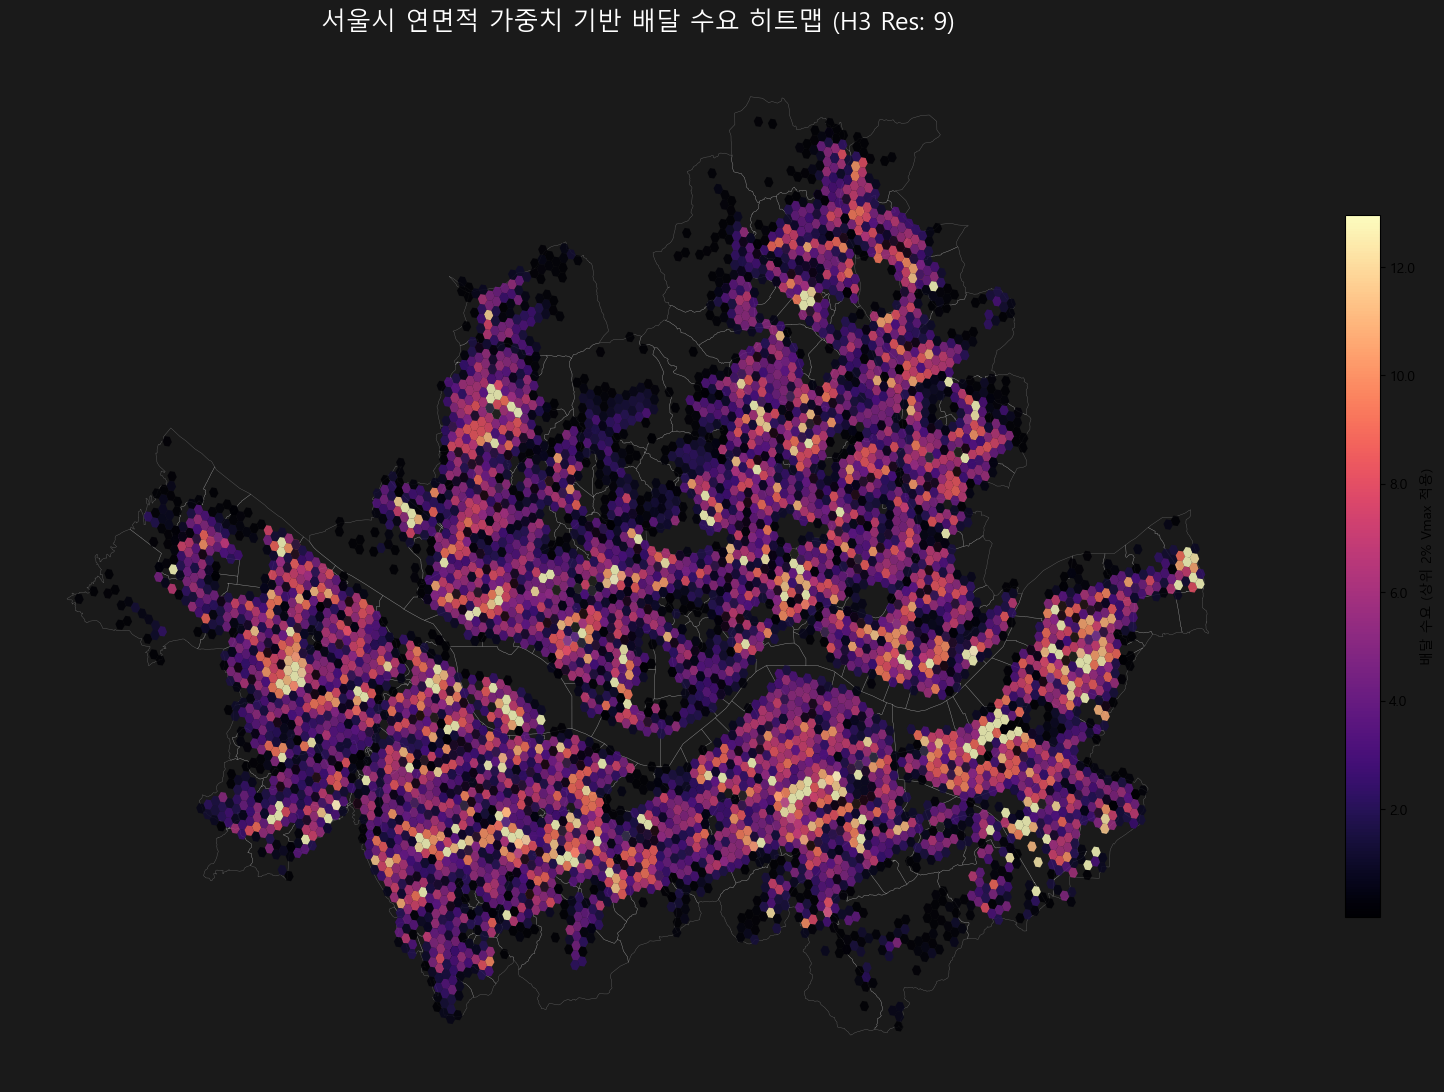

In [11]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
import h3
import geopandas as gpd
import numpy as np

# 1. H3 인덱스를 Polygon(다각형) 공간 객체로 변환하는 함수
def get_h3_polygon(h3_index):
    try:
        coords = h3.h3_to_geo_boundary(h3_index, geo_json=True)
    except (AttributeError, TypeError):
        coords_lat_lng = h3.cell_to_boundary(h3_index)
        coords = [(lng, lat) for lat, lng in coords_lat_lng]
    return Polygon(coords)

print("H3 인덱스를 공간 데이터로 변환 중...")
viz_df = delivery_demand_h3.copy()
viz_df['geometry'] = viz_df['h3_index'].apply(get_h3_polygon)
gdf_h3_demand = gpd.GeoDataFrame(viz_df, geometry='geometry', crs="EPSG:4326")

# =====================================================================
# ★ 핵심 디버깅: 시각화 왜곡 제어 (필터링 & 색상 스케일링)
# =====================================================================
# 1) 노이즈 제거: 하위 15%의 셀(산, 강, 화장실 등 수요가 거의 없는 곳)은 투명하게 뚫리도록 제외
threshold = np.percentile(gdf_h3_demand['h3_demand_index'], 15)
gdf_h3_viz = gdf_h3_demand[gdf_h3_demand['h3_demand_index'] > threshold]

# 2) 색상 왜곡 방지: 상위 2% 랜드마크 아웃라이어 수치를 기준으로 색상 최대치(vmax) 설정
# (이렇게 하면 0~2점에 몰려있던 색상이 다채로운 주황/노란색으로 살아납니다)
vmax_val = np.percentile(gdf_h3_viz['h3_demand_index'], 98)


# 2. 정적 지도 시각화 설정
fig, ax = plt.subplots(figsize=(16, 12))
fig.patch.set_facecolor('#1a1a1a')
ax.set_facecolor('#1a1a1a')

# 3. 서울시 행정동 경계선 레이어 (배경 컨텍스트)
dong_polygons.plot(
    ax=ax, 
    facecolor='none', 
    edgecolor='white', 
    linewidth=0.3, 
    alpha=0.3, 
    zorder=1
)

# 4. H3 배달 수요 히트맵 레이어 플로팅 (수정된 데이터셋 적용)
gdf_h3_viz.plot(
    ax=ax,
    column='h3_demand_index',  
    cmap='magma',              
    vmax=vmax_val,             # ★ 극단치 제한 (색상 스케일링)
    legend=True,
    legend_kwds={
        'shrink': 0.6, 
        'label': '배달 수요 (상위 2% Vmax 적용)', 
        'format': '%.1f'
    },
    edgecolor='none',
    alpha=0.85,
    zorder=2
)

ax.set_title("서울시 연면적 가중치 기반 배달 수요 히트맵 (H3 Res: 9)", color='white', fontsize=18, pad=15)
ax.axis('off')

plt.tight_layout()
plt.show()

In [12]:
# Cell 10: 3개의 데이터셋 Parquet 포맷으로 저장
delivery_demand_dong.to_parquet(OUT / "delivery_demand_dong.parquet", index=False)
hourly_demand.to_parquet(OUT / "hourly_demand.parquet", index=False)

#(Cell 9를 정상적으로 실행했다면 아래 주석을 해제하고 저장하세요)
delivery_demand_h3.to_parquet(OUT / "delivery_demand_h3.parquet", index=False)

print("✅ 모든 Parquet 파일 저장이 완료되었습니다!")
print(f"저장 위치: {OUT}")

✅ 모든 Parquet 파일 저장이 완료되었습니다!
저장 위치: C:\Users\jimin\Desktop\1_BITAmin_16기\skybase-seoul\skybase-seoul-v3\processed


In [13]:
import geopandas as gpd
from shapely.geometry import Polygon
import h3

# 1. H3 인덱스를 육각형 폴리곤으로 변환하는 함수 정의
def h3_to_polygon(h3_index):
    # h3 v4 기준: cell_to_boundary / h3 v3 기준: h3_to_geo_boundary
    try:
        boundary = h3.cell_to_boundary(h3_index)
    except AttributeError:
        boundary = h3.h3_to_geo_boundary(h3_index)
    
    # 위도, 경도 순서를 경도, 위도로 뒤집어서 Polygon 생성 (GIS 표준)
    return Polygon([(lng, lat) for lat, lng in boundary])

# 2. Geometry 컬럼 생성
print("육각형 폴리곤 생성 중...")
delivery_demand_h3['geometry'] = delivery_demand_h3['h3_index'].apply(h3_to_polygon)

# 3. GeoDataFrame으로 변환
# EPSG:4326은 위경도 좌표계입니다.
gdf_h3 = gpd.GeoDataFrame(delivery_demand_h3, geometry='geometry', crs="EPSG:4326")

# 4. GPKG 파일로 저장
output_path = OUT / "delivery_demand_h3.gpkg"
gdf_h3.to_file(output_path, driver="GPKG", layer="demand_h3")

print(f"✅ GPKG 파일 저장이 완료되었습니다!")
print(f"저장 위치: {output_path}")

육각형 폴리곤 생성 중...
✅ GPKG 파일 저장이 완료되었습니다!
저장 위치: C:\Users\jimin\Desktop\1_BITAmin_16기\skybase-seoul\skybase-seoul-v3\processed\delivery_demand_h3.gpkg
